In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
base_path = "/content/drive/MyDrive/2026-Summer/IDXExchange-Intern/"

train_df = pd.read_csv(f"{base_path}/split-data/cleaned_train.csv")
validation_df = pd.read_csv(f"{base_path}/split-data/cleaned_validation.csv")
test_df = pd.read_csv(f"{base_path}/split-data/cleaned_test.csv")

for frame in [train_df, validation_df, test_df]:
    frame["CloseDate"] = pd.to_datetime(frame["CloseDate"])

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain period:",
      train_df["CloseDate"].min(), "to", train_df["CloseDate"].max())
print("Validation period:",
      validation_df["CloseDate"].min(), "to", validation_df["CloseDate"].max())
print("Test period:",
      test_df["CloseDate"].min(), "to", test_df["CloseDate"].max())

Train shape: (129555, 40)
Validation shape: (31758, 40)
Test shape: (12024, 40)

Train period: 2025-02-01 00:00:00 to 2026-01-31 00:00:00
Validation period: 2026-02-01 00:00:00 to 2026-04-30 00:00:00
Test period: 2026-05-01 00:00:00 to 2026-05-31 00:00:00


In [4]:
target = "ClosePrice"
exclude_cols = [target, "CloseDate", "split"]

feature_cols = [
    col for col in train_df.columns
    if col not in exclude_cols
]

X_train = train_df[feature_cols].copy()
X_validation = validation_df.reindex(columns=feature_cols, fill_value=0).copy()
X_test = test_df.reindex(columns=feature_cols, fill_value=0).copy()

y_train = train_df[target].copy()
y_validation = validation_df[target].copy()
y_test = test_df[target].copy()

print("Number of model features:", len(feature_cols))
print("\nFeature dtype counts:")
print(X_train.dtypes.value_counts())

print("\nNon-numeric columns:")
print(X_train.select_dtypes(exclude="number").columns.tolist())

print("\nMissing-value totals:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_validation.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

print("\nInfinite-value totals:")
print("Train:", np.isinf(X_train.select_dtypes(include="number")).sum().sum())
print("Validation:", np.isinf(X_validation.select_dtypes(include="number")).sum().sum())
print("Test:", np.isinf(X_test.select_dtypes(include="number")).sum().sum())

Number of model features: 37

Feature dtype counts:
float64    24
int64      13
Name: count, dtype: int64

Non-numeric columns:
[]

Missing-value totals:
Train: 0
Validation: 0
Test: 0

Infinite-value totals:
Train: 0
Validation: 0
Test: 0


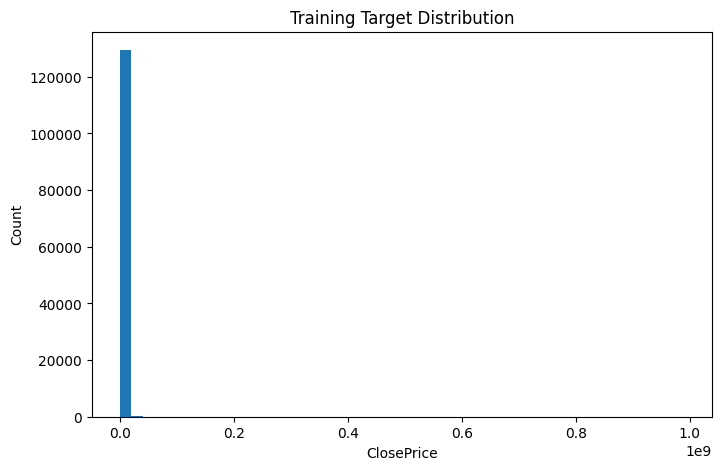

In [5]:
# Target Distribution

plt.figure(figsize=(8, 5))
plt.hist(y_train, bins=50)
plt.title("Training Target Distribution")
plt.xlabel("ClosePrice")
plt.ylabel("Count")
plt.show()

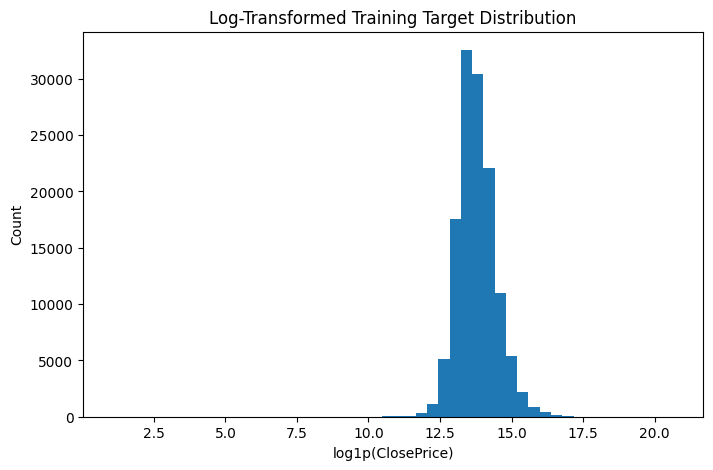

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(y_train), bins=50)
plt.title("Log-Transformed Training Target Distribution")
plt.xlabel("log1p(ClosePrice)")
plt.ylabel("Count")
plt.show()

In [7]:
# Correlation

numeric_train = train_df.select_dtypes(include="number")
target_corr = (
    numeric_train.corr()[target]
    .drop(target)
    .dropna()
    .sort_values(ascending=False)
)

top_positive = target_corr.head(15)
top_negative = target_corr.tail(15)

print("Top positive correlations:")
display(top_positive.to_frame("Correlation"))

print("\nTop negative correlations:")
display(top_negative.to_frame("Correlation"))

Top positive correlations:


,Correlation
LivingArea,0.124887
PostalCode_encoded,0.121099
City_encoded,0.116523
MLSAreaMajor_encoded,0.111173
BathroomsTotalInteger,0.110379
HighSchoolDistrict_encoded,0.072789
BedroomsTotal,0.070057
CountyOrParish_encoded,0.065691
PoolPrivateYN_Missing,0.040746
Stories_missing,0.036048



Top negative correlations:


,Correlation
YearBuilt,0.002053
ParkingTotal_missing,0.001278
ParkingTotal,0.001047
LotSizeSquareFeet,0.000916
Longitude_missing,0.000873
Latitude_missing,0.000873
LotSizeArea_missing,0.000746
LotSizeAcres,0.000744
LotSizeSquareFeet_missing,0.000726
LotSizeAcres_missing,0.000715


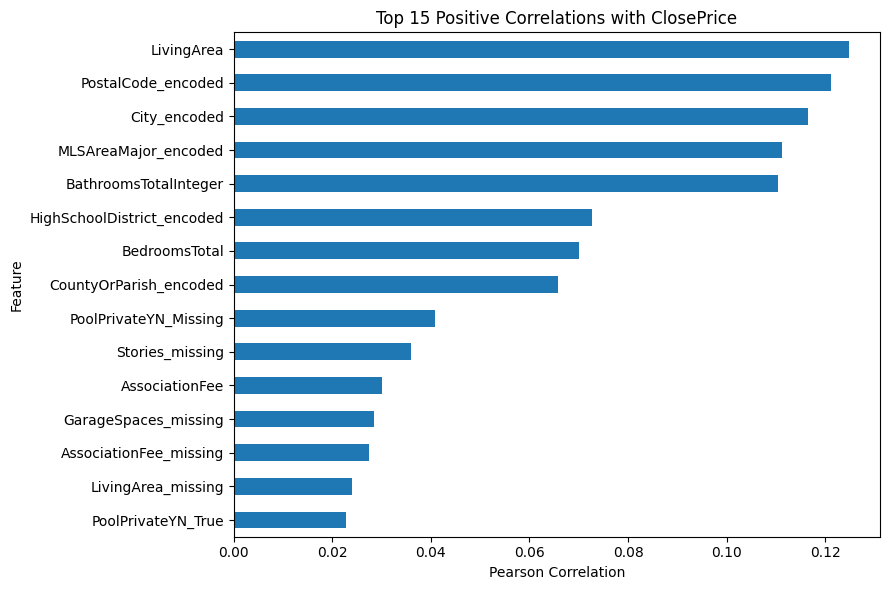

In [8]:
plt.figure(figsize=(9, 6))
top_positive.sort_values().plot(kind="barh")
plt.title("Top 15 Positive Correlations with ClosePrice")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

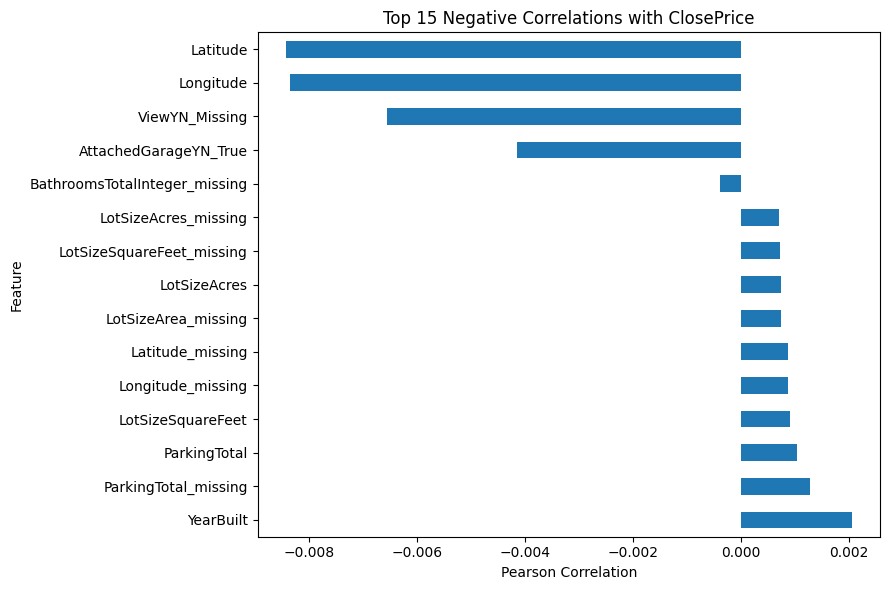

In [9]:
plt.figure(figsize=(9, 6))
top_negative.plot(kind="barh")
plt.title("Top 15 Negative Correlations with ClosePrice")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

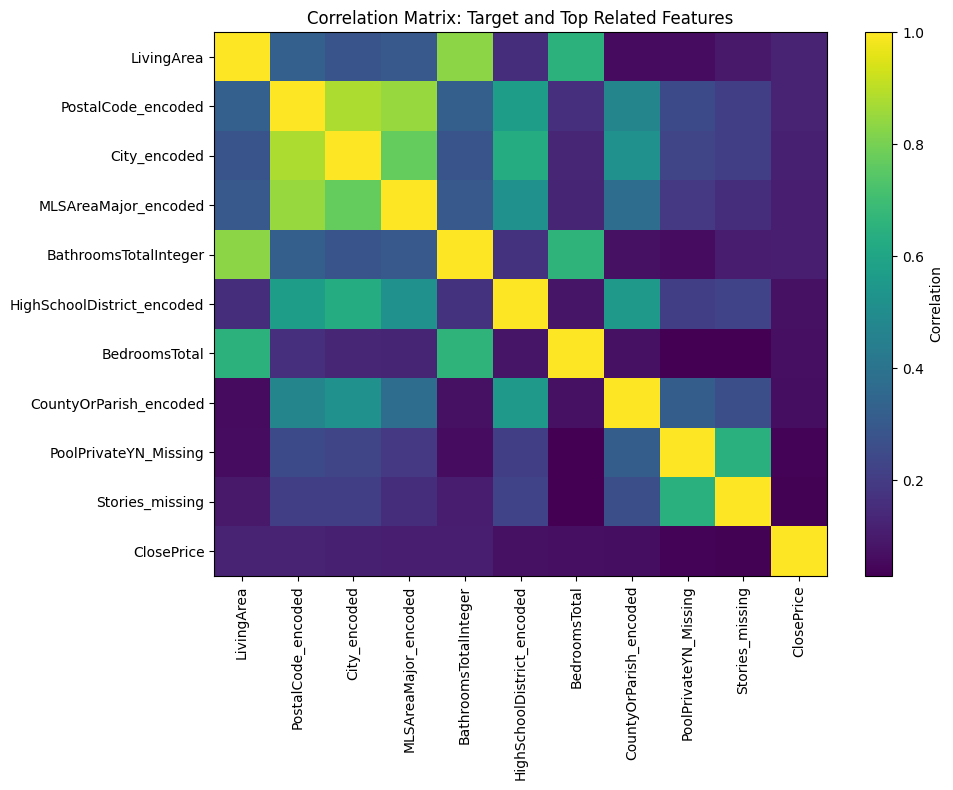

In [10]:
heatmap_features = (
    target_corr.abs()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

heatmap_cols = heatmap_features + [target]
corr_matrix = numeric_train[heatmap_cols].corr()

plt.figure(figsize=(10, 8))
image = plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(image, label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

plt.title("Correlation Matrix: Target and Top Related Features")
plt.tight_layout()
plt.show()

In [11]:
# Helper

def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


def train_and_predict(
    train_data,
    evaluation_data,
    feature_cols,
    target,
    use_log_target=False
):
    X_fit = train_data.reindex(columns=feature_cols, fill_value=0)
    y_fit = train_data[target]

    X_eval = evaluation_data.reindex(columns=feature_cols, fill_value=0)

    scaler = StandardScaler()
    X_fit_scaled = scaler.fit_transform(X_fit)
    X_eval_scaled = scaler.transform(X_eval)

    model = LinearRegression()

    if use_log_target:
        model.fit(X_fit_scaled, np.log1p(y_fit))
        predictions = np.expm1(model.predict(X_eval_scaled))
    else:
        model.fit(X_fit_scaled, y_fit)
        predictions = model.predict(X_eval_scaled)

    return model, scaler, predictions


def get_training_window(train_data, evaluation_start, months):
    window_start = evaluation_start - pd.DateOffset(months=months)

    return train_data[
        (train_data["CloseDate"] >= window_start) &
        (train_data["CloseDate"] < evaluation_start)
    ].copy()

In [12]:
# Training Baseline Model

baseline_results = []

for model_name, use_log_target in [
    ("Linear Regression", False),
    ("Log-Target Linear Regression", True),
]:
    model, scaler, validation_pred = train_and_predict(
        train_df,
        validation_df,
        feature_cols,
        target,
        use_log_target=use_log_target
    )

    metrics = regression_metrics(y_validation, validation_pred)

    baseline_results.append({
        "Model": model_name,
        "Training Window": "Full training period",
        "Train Rows": len(train_df),
        "Validation R2": metrics["R2"],
        "Validation RMSE": metrics["RMSE"],
        "Validation MAE": metrics["MAE"],
    })

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df

,Model,Training Window,Train Rows,Validation R2,Validation RMSE,Validation MAE
0,Linear Regression,Full training period,129555,0.015278,9.655661e+06,541209.738950
1,Log-Target Linear Regression,Full training period,129555,-0.158460,1.047287e+07,540382.853766


In [13]:
# Comparison

window_results = []
validation_start = validation_df["CloseDate"].min()

for months in [3, 6, 9, 12]:
    window_train = get_training_window(
        train_df,
        validation_start,
        months
    )

    for model_name, use_log_target in [
        ("Linear Regression", False),
        ("Log-Target Linear Regression", True),
    ]:
        model, scaler, validation_pred = train_and_predict(
            window_train,
            validation_df,
            feature_cols,
            target,
            use_log_target=use_log_target
        )

        metrics = regression_metrics(
            y_validation,
            validation_pred
        )

        window_results.append({
            "Model": model_name,
            "Months": months,
            "Training Window": f"{months} months",
            "Train Rows": len(window_train),
            "Validation R2": metrics["R2"],
            "Validation RMSE": metrics["RMSE"],
            "Validation MAE": metrics["MAE"],
        })

window_results_df = pd.DataFrame(window_results)
window_results_df.sort_values(
    "Validation R2",
    ascending=False
).reset_index(drop=True)

,Model,Months,Training Window,Train Rows,Validation R2,Validation RMSE,Validation MAE
0,Linear Regression,3,3 months,27684,0.015279,9.655655e+06,512612.509236
1,Linear Regression,12,12 months,129555,0.015278,9.655661e+06,541209.738950
2,Linear Regression,6,6 months,62623,0.015101,9.656531e+06,525386.051450
3,Linear Regression,9,9 months,98214,0.010263,9.680215e+06,572285.006761
4,Log-Target Linear Regression,9,9 months,98214,-0.142468,1.040033e+07,537273.897177
5,Log-Target Linear Regression,12,12 months,129555,-0.158460,1.047287e+07,540382.853766
6,Log-Target Linear Regression,6,6 months,62623,-0.186695,1.059973e+07,546826.670003
7,Log-Target Linear Regression,3,3 months,27684,-0.191857,1.062276e+07,547745.823374


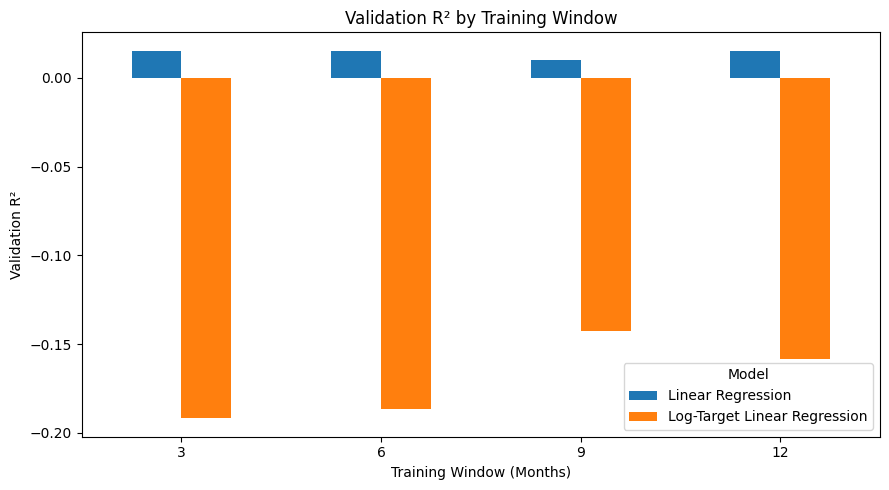

In [14]:
# R2

r2_pivot = window_results_df.pivot(
    index="Months",
    columns="Model",
    values="Validation R2"
)

r2_pivot.plot(kind="bar", figsize=(9, 5))
plt.title("Validation R² by Training Window")
plt.xlabel("Training Window (Months)")
plt.ylabel("Validation R²")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

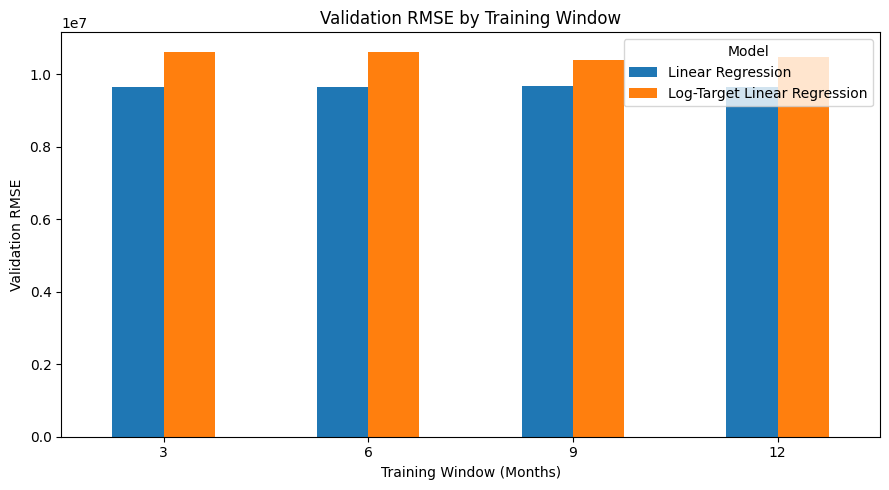

In [15]:
# RMSE

rmse_pivot = window_results_df.pivot(
    index="Months",
    columns="Model",
    values="Validation RMSE"
)

rmse_pivot.plot(kind="bar", figsize=(9, 5))
plt.title("Validation RMSE by Training Window")
plt.xlabel("Training Window (Months)")
plt.ylabel("Validation RMSE")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

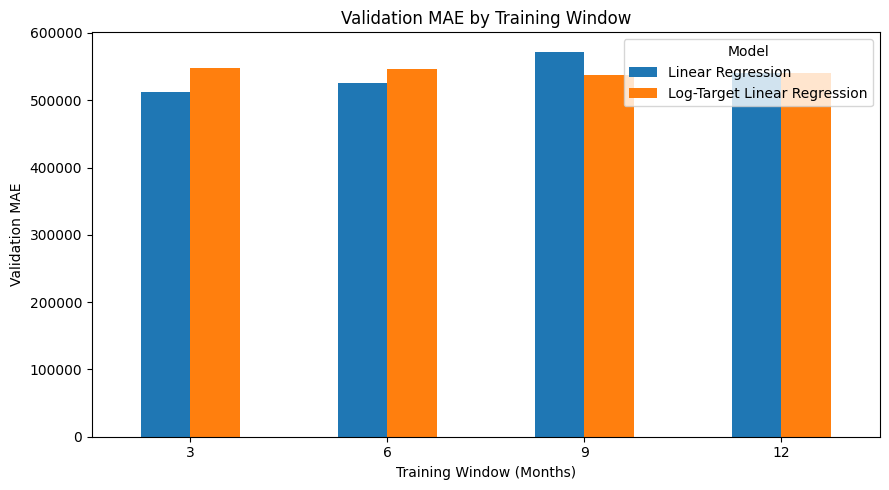

In [16]:
# MAE

mae_pivot = window_results_df.pivot(
    index="Months",
    columns="Model",
    values="Validation MAE"
)

mae_pivot.plot(kind="bar", figsize=(9, 5))
plt.title("Validation MAE by Training Window")
plt.xlabel("Training Window (Months)")
plt.ylabel("Validation MAE")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [17]:
# Best Validation Model

ranked_validation_results = (
    window_results_df
    .sort_values(
        ["Validation R2", "Validation RMSE", "Validation MAE"],
        ascending=[False, True, True]
    )
    .reset_index(drop=True)
)

best_validation_row = ranked_validation_results.iloc[0]

best_model_name = best_validation_row["Model"]
best_months = int(best_validation_row["Months"])
best_use_log_target = best_model_name == "Log-Target Linear Regression"

print("Selected model:", best_model_name)
print("Selected training window:", f"{best_months} months")
print(f"Validation R²: {best_validation_row['Validation R2']:.4f}")
print(f"Validation RMSE: ${best_validation_row['Validation RMSE']:,.2f}")
print(f"Validation MAE: ${best_validation_row['Validation MAE']:,.2f}")

ranked_validation_results

Selected model: Linear Regression
Selected training window: 3 months
Validation R²: 0.0153
Validation RMSE: $9,655,654.98
Validation MAE: $512,612.51


,Model,Months,Training Window,Train Rows,Validation R2,Validation RMSE,Validation MAE
0,Linear Regression,3,3 months,27684,0.015279,9.655655e+06,512612.509236
1,Linear Regression,12,12 months,129555,0.015278,9.655661e+06,541209.738950
2,Linear Regression,6,6 months,62623,0.015101,9.656531e+06,525386.051450
3,Linear Regression,9,9 months,98214,0.010263,9.680215e+06,572285.006761
4,Log-Target Linear Regression,9,9 months,98214,-0.142468,1.040033e+07,537273.897177
5,Log-Target Linear Regression,12,12 months,129555,-0.158460,1.047287e+07,540382.853766
6,Log-Target Linear Regression,6,6 months,62623,-0.186695,1.059973e+07,546826.670003
7,Log-Target Linear Regression,3,3 months,27684,-0.191857,1.062276e+07,547745.823374


In [18]:
# Validation diagnostics

selected_window_train = get_training_window(
    train_df,
    validation_start,
    best_months
)

selected_validation_model, selected_validation_scaler, selected_validation_pred = train_and_predict(
    selected_window_train,
    validation_df,
    feature_cols,
    target,
    use_log_target=best_use_log_target
)

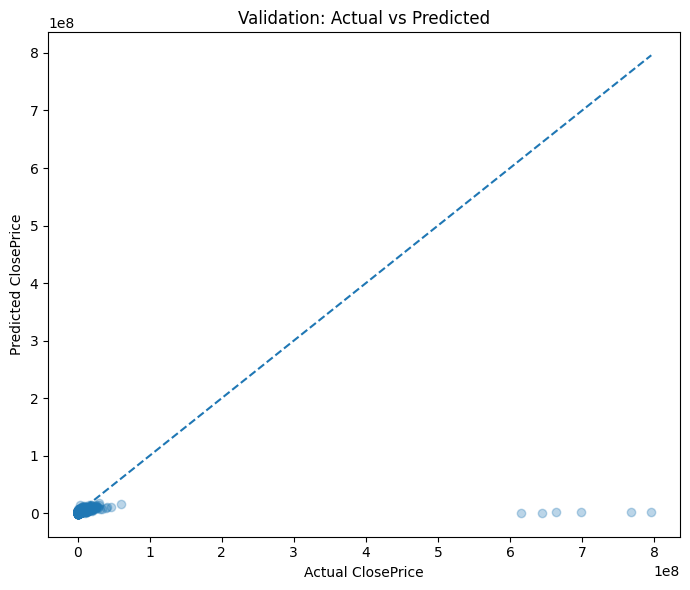

In [19]:
plt.figure(figsize=(7, 6))
plt.scatter(y_validation, selected_validation_pred, alpha=0.3)

min_value = min(
    y_validation.min(),
    selected_validation_pred.min()
)
max_value = max(
    y_validation.max(),
    selected_validation_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Validation: Actual vs Predicted")
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.tight_layout()
plt.show()

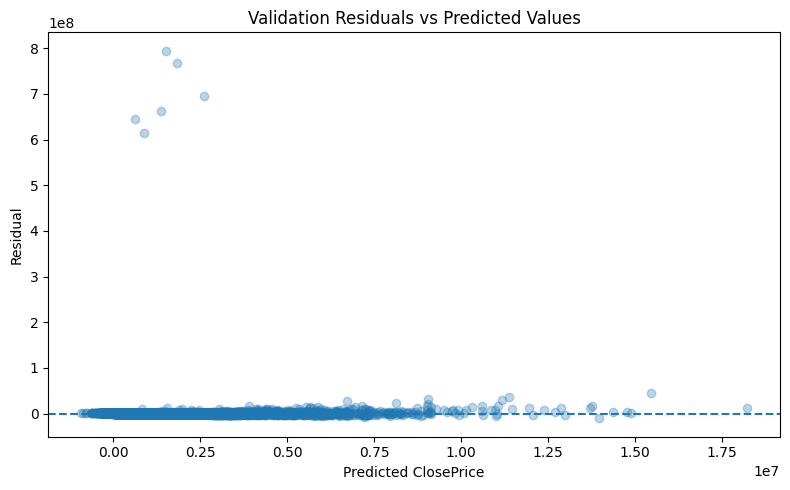

In [20]:
validation_residuals = y_validation - selected_validation_pred

plt.figure(figsize=(8, 5))
plt.scatter(
    selected_validation_pred,
    validation_residuals,
    alpha=0.3
)
plt.axhline(0, linestyle="--")
plt.title("Validation Residuals vs Predicted Values")
plt.xlabel("Predicted ClosePrice")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

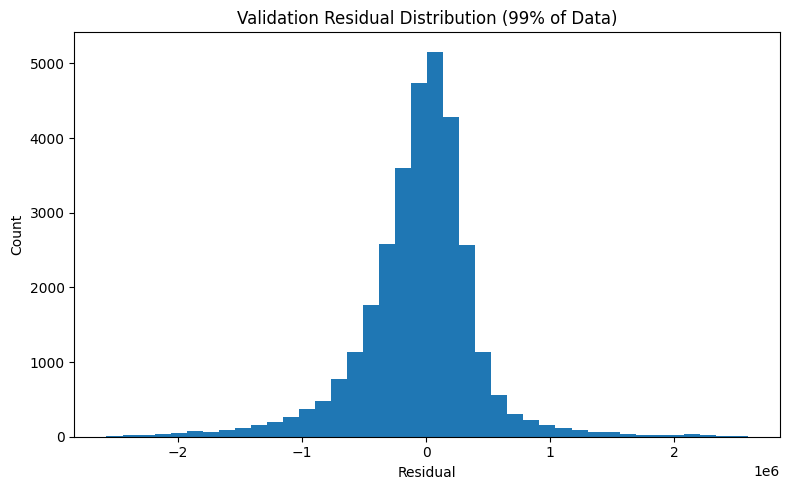

In [21]:
validation_limit = validation_residuals.abs().quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    validation_residuals[
        validation_residuals.abs() <= validation_limit
    ],
    bins=40
)
plt.title("Validation Residual Distribution (99% of Data)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [22]:
# Final model and Test Evaluation

test_start = test_df["CloseDate"].min()

historical_window_start = (
    validation_start -
    pd.DateOffset(months=best_months)
)

historical_train = train_df[
    (train_df["CloseDate"] >= historical_window_start) &
    (train_df["CloseDate"] < validation_start)
].copy()

final_fit_df = pd.concat(
    [historical_train, validation_df],
    ignore_index=True
).sort_values("CloseDate")

final_model, final_scaler, test_pred = train_and_predict(
    final_fit_df,
    test_df,
    feature_cols,
    target,
    use_log_target=best_use_log_target
)

test_metrics = regression_metrics(y_test, test_pred)

print("Final selected model:", best_model_name)
print("Selected historical window:", f"{best_months} months")
print("Final training rows:", len(final_fit_df))
print(f"Test R²: {test_metrics['R2']:.4f}")
print(f"Test RMSE: ${test_metrics['RMSE']:,.2f}")
print(f"Test MAE: ${test_metrics['MAE']:,.2f}")

Final selected model: Linear Regression
Selected historical window: 3 months
Final training rows: 59442
Test R²: 0.4368
Test RMSE: $1,259,301.78
Test MAE: $417,364.94


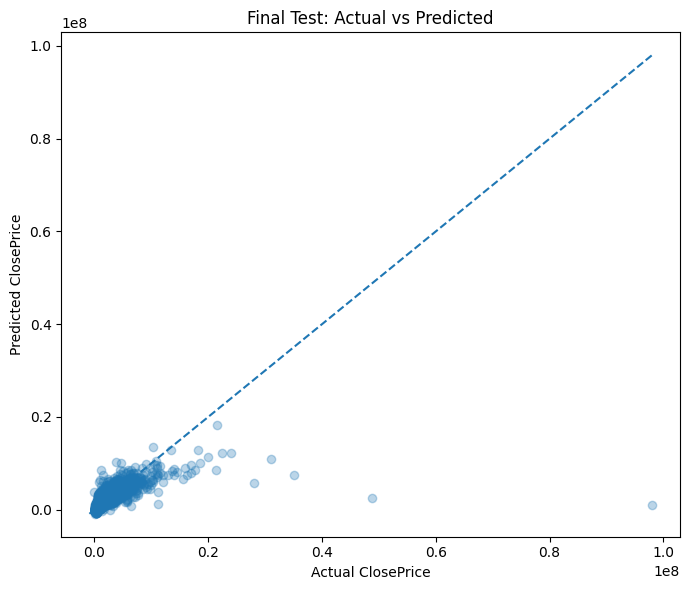

In [23]:
# Final Test Plots

plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.3)

min_value = min(y_test.min(), test_pred.min())
max_value = max(y_test.max(), test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Final Test: Actual vs Predicted")
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.tight_layout()
plt.show()

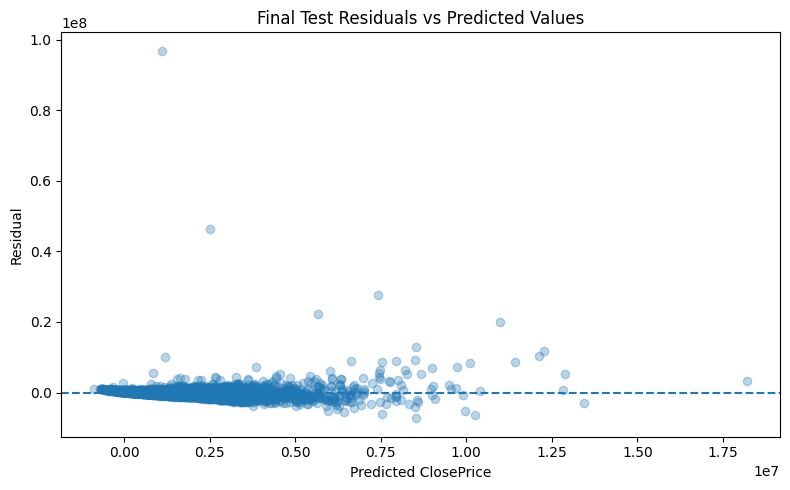

In [24]:
test_residuals = y_test - test_pred

plt.figure(figsize=(8, 5))
plt.scatter(test_pred, test_residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title("Final Test Residuals vs Predicted Values")
plt.xlabel("Predicted ClosePrice")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

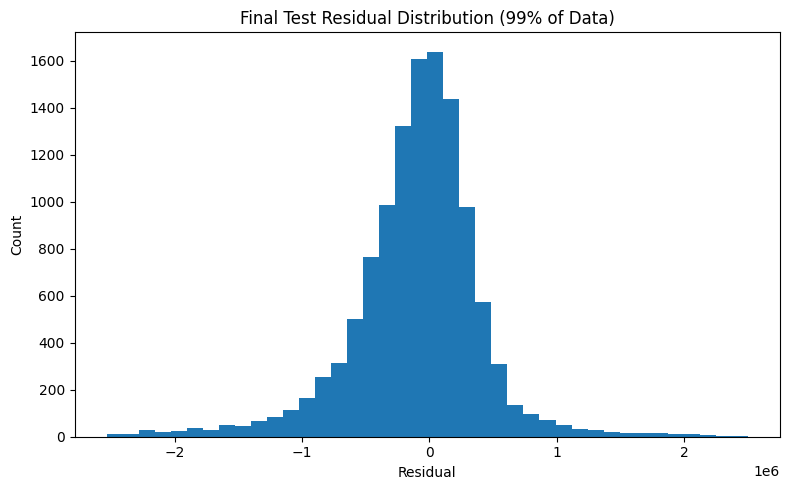

In [25]:
test_limit = test_residuals.abs().quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    test_residuals[test_residuals.abs() <= test_limit],
    bins=40
)
plt.title("Final Test Residual Distribution (99% of Data)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

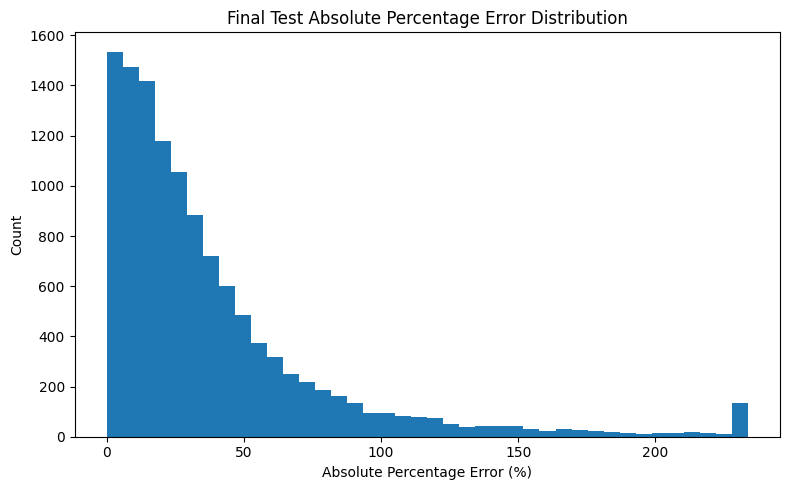

In [26]:
absolute_percentage_error = (
    np.abs(y_test - test_pred) /
    y_test.replace(0, np.nan)
) * 100

plt.figure(figsize=(8, 5))
plt.hist(
    absolute_percentage_error.dropna().clip(
        upper=absolute_percentage_error.quantile(0.99)
    ),
    bins=40
)
plt.title("Final Test Absolute Percentage Error Distribution")
plt.xlabel("Absolute Percentage Error (%)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [27]:
# Coefficient

coefficient_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": final_model.coef_
})

coefficient_df["Absolute Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

top_coefficients = (
    coefficient_df
    .sort_values(
        "Absolute Coefficient",
        ascending=False
    )
    .head(20)
    .sort_values("Coefficient")
)

top_coefficients

,Feature,Coefficient,Absolute Coefficient
6,Stories,-203271.748469,203271.748469
3,BedroomsTotal,-130881.140058,130881.140058
5,YearBuilt,-111689.015865,111689.015865
0,Latitude,-86814.060709,86814.060709
34,PoolPrivateYN_True,-80495.555436,80495.555436
25,LotSizeArea_missing,-44945.951388,44945.951388
22,AssociationFee_missing,-32412.962879,32412.962879
31,ViewYN_Missing,28616.278488,28616.278488
9,AssociationFee,29366.616819,29366.616819
18,YearBuilt_missing,35871.597339,35871.597339


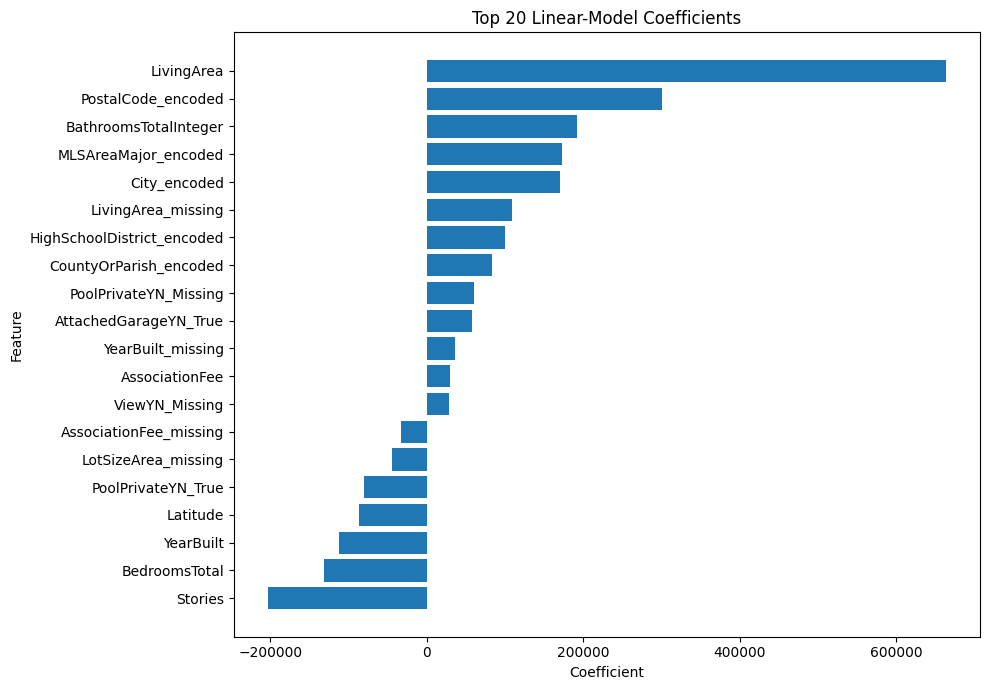

In [28]:
plt.figure(figsize=(10, 7))
plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)
plt.title("Top 20 Linear-Model Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [29]:
# Metric Comparison

final_summary = pd.DataFrame({
    "Selected Model": [best_model_name],
    "Selected Training Window": [f"{best_months} months"],
    "Validation R2": [best_validation_row["Validation R2"]],
    "Validation RMSE": [best_validation_row["Validation RMSE"]],
    "Validation MAE": [best_validation_row["Validation MAE"]],
    "Test R2": [test_metrics["R2"]],
    "Test RMSE": [test_metrics["RMSE"]],
    "Test MAE": [test_metrics["MAE"]],
})

final_summary

,Selected Model,Selected Training Window,Validation R2,Validation RMSE,Validation MAE,Test R2,Test RMSE,Test MAE
0,Linear Regression,3 months,0.015279,9.655655e+06,512612.509236,0.436823,1.259302e+06,417364.936795


In [30]:
metric_comparison = pd.DataFrame({
    "Dataset": ["Validation", "Test"],
    "R2": [
        best_validation_row["Validation R2"],
        test_metrics["R2"],
    ],
    "RMSE": [
        best_validation_row["Validation RMSE"],
        test_metrics["RMSE"],
    ],
    "MAE": [
        best_validation_row["Validation MAE"],
        test_metrics["MAE"],
    ],
})

metric_comparison

,Dataset,R2,RMSE,MAE
0,Validation,0.015279,9.655655e+06,512612.509236
1,Test,0.436823,1.259302e+06,417364.936795


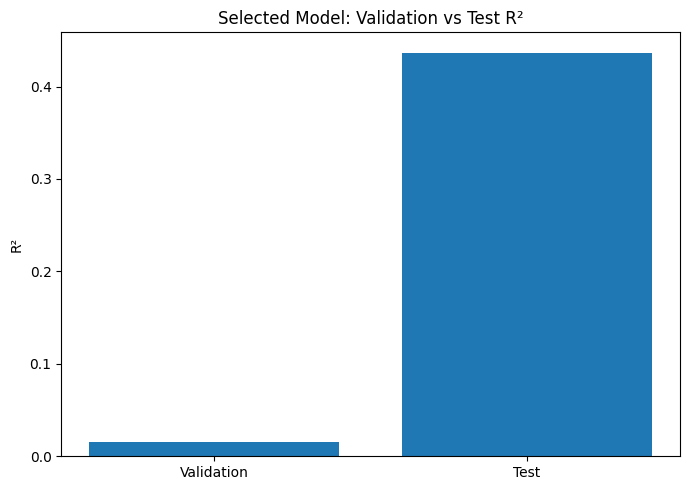

In [31]:
plt.figure(figsize=(7, 5))
plt.bar(
    metric_comparison["Dataset"],
    metric_comparison["R2"]
)
plt.title("Selected Model: Validation vs Test R²")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

In [32]:
# Save Outputs

window_results_df.to_csv(
    f"{base_path}/training_window_results.csv",
    index=False
)

coefficient_df.to_csv(
    f"{base_path}/linear_model_coefficients.csv",
    index=False
)

final_summary.to_csv(
    f"{base_path}/baseline_results.csv",
    index=False
)

prediction_output = test_df[["CloseDate", target]].copy()
prediction_output["PredictedClosePrice"] = test_pred
prediction_output["Residual"] = test_residuals
prediction_output["AbsoluteError"] = np.abs(test_residuals)

prediction_output.to_csv(
    f"{base_path}/baseline_test_predictions.csv",
    index=False
)

print("Saved:")
print("- training_window_results.csv")
print("- linear_model_coefficients.csv")
print("- baseline_results.csv")
print("- baseline_test_predictions.csv")

Saved:
- training_window_results.csv
- linear_model_coefficients.csv
- baseline_results.csv
- baseline_test_predictions.csv
